# 4. EVT и AR baseline

**Цель:** честно сравнить точечную POT-детекцию с эвристикой по AR-остаткам. Ни один метод не объявляется победителем заранее.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))

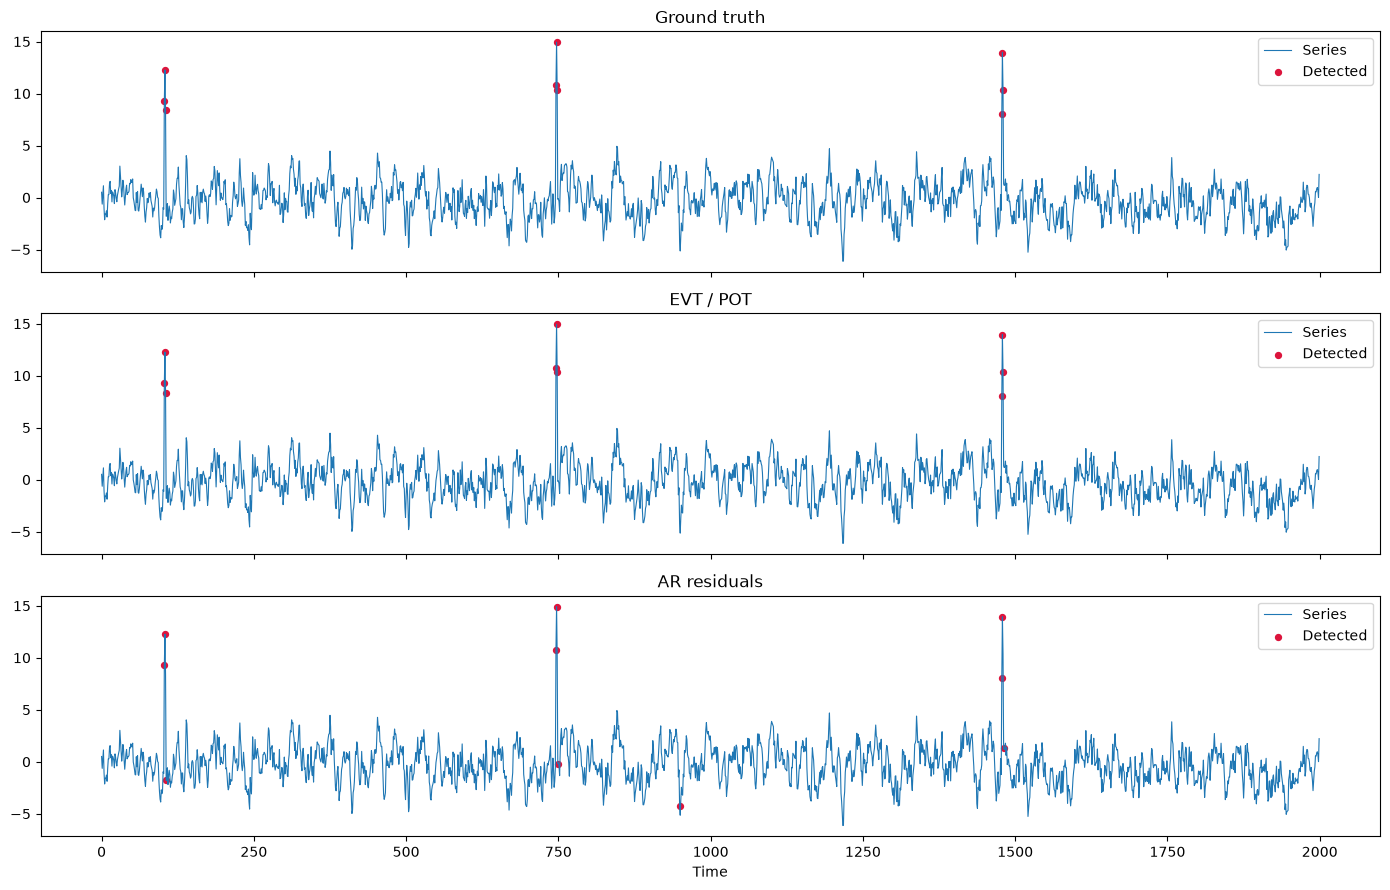

{'EVT': {'precision': 1.0, 'recall': 1.0, 'f1': 1.0},
 'AR': {'precision': 0.6,
  'recall': 0.6666666666666666,
  'f1': 0.631578947368421}}

In [4]:
from evt_demo import EVTAnalyzer, AutoregressiveModel, generate_time_series_with_extreme_events
import evt_demo.visualization
from sklearn.metrics import precision_score, recall_score, f1_score
series, truth=generate_time_series_with_extreme_events(seed=42)
a=EVTAnalyzer(); gpd=a.fit_gpd_peaks_over_threshold(series); evt=a.detect_extremes_via_pot(series,gpd,.05)
ar=AutoregressiveModel(1).fit(series); ar_mask=ar.detect_anomalies_via_residuals(series)
import matplotlib.pyplot as plt

output_path = Path("../figures/notebook_04_comparison.png")
output_path.parent.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

for ax, mask, title in zip(
    axes,
    (truth, evt, ar_mask),
    ("Ground truth", "EVT / POT", "AR residuals"),
):
    ax.plot(series, linewidth=0.8, label="Series")
    indices = mask.nonzero()[0]
    ax.scatter(indices, series[indices], s=18, color="crimson", label="Detected")
    ax.set_title(title)
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Time")
fig.tight_layout()
fig.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)
{name: {"precision": precision_score(truth,m,zero_division=0), "recall": recall_score(truth,m,zero_division=0), "f1": f1_score(truth,m,zero_division=0)} for name,m in [("EVT",evt),("AR",ar_mask)]}

Метрики относятся только к выбранному генератору и порогам. AR полезен для условного среднего, EVT — для хвоста; это разные цели.

**Самопроверка:** 1) Как обеспечить честный train/test? 2) Почему нельзя размечать весь блок? 3) Как меняются метрики с порогом? 4) Какие зависимости нарушают предпосылки?